## License

This code is licensed under the Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International License (CC BY-NC-SA 4.0).  
You are free to use and modify the code for non-commercial research and educational purposes, provided that you give appropriate credit and distribute derivatives under the same license.

In [ ]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# Pfade
# ---------------------------
results_dir = "/YourfolderPath/results_CSV_forPaper"
plot_dir    = "/YourfolderPath/PaperPlots/AllSubjectsTogether"
os.makedirs(plot_dir, exist_ok=True)

# Optional: Labels/Farben für verschiedene session_id
SESSION_LABELS = {
    "RR_Intervals": "RR-Intervals",
    "HeartMovement": "Heart Movement",
    "VectorLength_R": "Vector Length R",
    "Ensemble_RR_plus_HM": "Ensemble (RR+HM)",
}
SESSION_COLORS = {
    "RR_Intervals": "tab:blue",
    "HeartMovement": "tab:orange",
    "VectorLength_R": "tab:green",
    "Ensemble_RR_plus_HM": "tab:red",
}

# ---------------------------
# Alle CSVs laden & zusammenführen
# ---------------------------
files = glob.glob(os.path.join(results_dir, "*_EDR_Quality.csv"))
dfs = [pd.read_csv(f) for f in files]
df_all = pd.concat(dfs, ignore_index=True)

# Anzahl Zeilen
print("Anzahl Zeilen gesamt:", len(df_all))

# Eindeutige Subject-IDs bestimmen
unique_subjects = df_all["subject_id"].unique()
n_subjects = len(unique_subjects)

print(f"Anzahl eindeutiger Subjects: {n_subjects}")
print("Subjects:", ", ".join(sorted(unique_subjects)))

# Übersicht Subject x Session
print(df_all[["subject_id", "session_id"]]
      .drop_duplicates()
      .sort_values(["subject_id", "session_id"]))

# ======================================================
# QC: Subjects mit schlechter SNR filtern
# ======================================================

# Welche Sessions sollen für die SNR-Qualität herangezogen werden?
methods_for_qc = ["RR_Intervals", "HeartMovement"]   # bei Bedarf anpassen
snr_thresh_db = 1.0   # Schwellwert in dB (z.B. 0 dB, 3 dB, ...)

df_qc = df_all[df_all["session_id"].isin(methods_for_qc)].copy()

# Pro Subject einen SNR-Kennwert: Median der snr_median_db über alle Segmente/Methoden
snr_by_subject = (
    df_qc.groupby("subject_id")["snr_median_db"]
         .median()                         # oder mean()
         .sort_values(ascending=False)
)

print("\nSNR-Qualität pro Subject (Median über snr_median_db):")
print(snr_by_subject)

good_subjects = snr_by_subject[snr_by_subject >= snr_thresh_db].index.tolist()
bad_subjects  = snr_by_subject[snr_by_subject <  snr_thresh_db].index.tolist()

print(f"\nSchwellwert für gute SNR: {snr_thresh_db:.1f} dB")
print(f"Anzahl 'gute' Subjects: {len(good_subjects)}")
print("Gute Subjects:", ", ".join(good_subjects) if good_subjects else "-")

print(f"\nAnzahl 'schlechte' Subjects: {len(bad_subjects)}")
print("Schlechte Subjects:", ", ".join(bad_subjects) if bad_subjects else "-")

# Zweites DF nur mit guten Subjects
df_all_good = df_all[df_all["subject_id"].isin(good_subjects)].reset_index(drop=True)
df_all_bad  = df_all[df_all["subject_id"].isin(bad_subjects)].reset_index(drop=True)

print(f"\nZeilen in df_all_good: {len(df_all_good)}")
print(f"Zeilen in df_all_bad:  {len(df_all_bad)}")


Anzahl Zeilen gesamt: 540
Anzahl eindeutiger Subjects: 20
Subjects: Subject30, Subject31, Subject32, Subject33, Subject36, Subject37, Subject38, Subject40, Subject42, Subject44, Subject45, Subject47, Subject48, Subject50, Subject52, Subject54, Subject55, Subject65, Subject66, Subject68
    subject_id           session_id
493  Subject30  Ensemble_RR_plus_HM
319  Subject30        HeartMovement
382  Subject30         RR_Intervals
507  Subject30       VectorLength_R
284  Subject31  Ensemble_RR_plus_HM
..         ...                  ...
479  Subject66       VectorLength_R
389  Subject68  Ensemble_RR_plus_HM
221  Subject68        HeartMovement
153  Subject68         RR_Intervals
235  Subject68       VectorLength_R

[80 rows x 2 columns]

SNR-Qualität pro Subject (Median über snr_median_db):
subject_id
Subject38    10.069350
Subject52     8.677426
Subject48     7.888765
Subject50     7.636263
Subject55     7.342386
Subject68     6.982638
Subject33     6.670534
Subject66     6.414235
Subject5

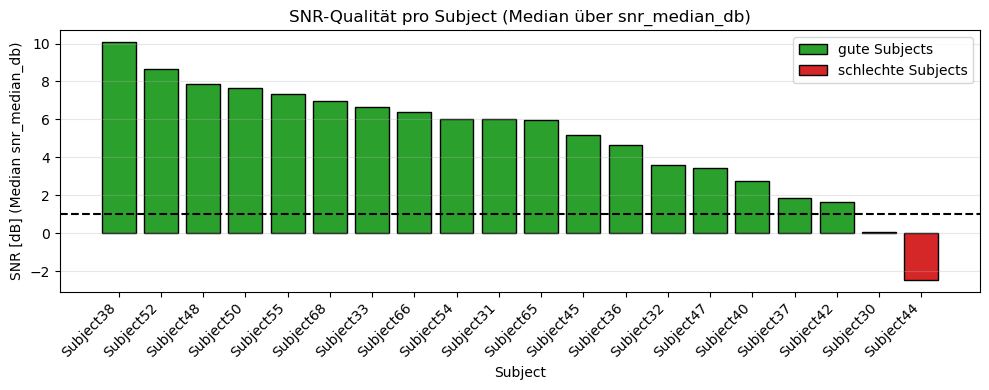

Balkenplot gespeichert in: /Users/felixkuon/Desktop/EKG-Projekt/MA_PythonCode/ExecutableFolder/PaperPlots/AllSubjectsTogether/AllSubjects_SNR_by_subject_thresh_1.0dB.png


In [3]:
# ======================================================
# Balkendiagramm: SNR pro Subject (gut/schlecht farblich)
# ======================================================

# Index und Werte in Arrays
subjects_sorted = snr_by_subject.index.to_numpy()
snr_values      = snr_by_subject.values

# Farbzuordnung: gute grün, schlechte rot
colors = []
for sid in subjects_sorted:
    if sid in good_subjects:
        colors.append("tab:green")
    else:
        colors.append("tab:red")

plt.figure(figsize=(10,4))

x = np.arange(len(subjects_sorted))
plt.bar(x, snr_values, color=colors, edgecolor="k")

# Schwellwert-Linie
plt.axhline(snr_thresh_db, color="k", linestyle="--", linewidth=1.5,
            label=f"SNR-Schwelle = {snr_thresh_db:.1f} dB")

plt.xticks(x, subjects_sorted, rotation=45, ha="right")
plt.ylabel("SNR [dB] (Median snr_median_db)")
plt.xlabel("Subject")
plt.title("SNR-Qualität pro Subject (Median über snr_median_db)")

# Legende für gut/schlecht
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor="tab:green", edgecolor="k", label="gute Subjects"),
    Patch(facecolor="tab:red",   edgecolor="k", label="schlechte Subjects")
]
plt.legend(handles=legend_handles, loc="best")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

fname_bar = os.path.join(plot_dir, f"AllSubjects_SNR_by_subject_thresh_{snr_thresh_db:.1f}dB.png")
plt.savefig(fname_bar, dpi=300)
plt.show()

print(f"Balkenplot gespeichert in: {fname_bar}")


In [4]:
def plot_all_snr_vs_bpm(df_all, session_ids=None, fname_suffix=""):
    """
    Aggregierter Plot SNR vs bpm über alle Subjekte.
    session_ids: Liste von session_id-Strings, z.B.
      ["RR_Intervals", "HeartMovement", "Ensemble_RR_plus_HM"]
      Wenn None: alle in df_all vorhandenen Session-IDs.
    """
    if session_ids is None:
        session_ids = sorted(df_all["session_id"].unique())

    group_snr = df_all.groupby(["bpm_target", "session_id"])["snr_median_db"]
    df_snr_summary = group_snr.agg(median="median", std="std", n="count").reset_index()

    plt.figure(figsize=(6,4))
    for sid in session_ids:
        sub = df_snr_summary[df_snr_summary["session_id"] == sid]
        if sub.empty:
            continue
        label = SESSION_LABELS.get(sid, sid)
        color = SESSION_COLORS.get(sid, "tab:gray")

        plt.errorbar(
            sub["bpm_target"], sub["median"], yerr=sub["std"],
            fmt='o', color=color, ecolor=color,
            elinewidth=1.5, capsize=4,
            label=f"{label} (median±std über Subjekte)"
        )

    plt.xlabel("True RESP [bpm]")
    plt.ylabel("SNR [dB]")
    plt.title("SNR der EDR-Schätzung pro Atemfrequenz (alle Subjekte)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    if not fname_suffix:
        fname_suffix = "_".join(session_ids)
    fname = f"AllSubjects_{fname_suffix}_SNR_vs_bpm.png"
    plt.savefig(os.path.join(plot_dir, fname), dpi=300)
    plt.show()


In [6]:
def plot_all_delta_ridge_power(df_all, session_ids=None, fname_suffix=""):
    """
    Aggregierter Plot: Δ Ridge-Power vs bpm (relativ zu 6 bpm) über alle Subjekte.
    """
    if session_ids is None:
        session_ids = sorted(df_all["session_id"].unique())

    df = df_all.copy()

    def compute_delta(group):
        if (group["bpm_target"] == 6).any():
            ref = group.loc[group["bpm_target"] == 6, "ridge_power_db"].iloc[0]
        else:
            idx_min = group["bpm_target"].idxmin()
            ref = group.loc[idx_min, "ridge_power_db"]
        group["ridge_power_delta_db"] = group["ridge_power_db"] - ref
        return group

    df = df.groupby(["subject_id", "session_id"], group_keys=False).apply(compute_delta)

    group_delta = df.groupby(["bpm_target", "session_id"])["ridge_power_delta_db"]
    df_delta_summary = group_delta.agg(median="median", std="std", n="count").reset_index()

    plt.figure(figsize=(6,4))
    for sid in session_ids:
        sub = df_delta_summary[df_delta_summary["session_id"] == sid]
        if sub.empty:
            continue
        label = SESSION_LABELS.get(sid, sid)
        color = SESSION_COLORS.get(sid, "tab:gray")

        plt.errorbar(
            sub["bpm_target"], sub["median"], yerr=sub["std"],
            fmt='o', color=color, ecolor=color,
            elinewidth=1.5, capsize=4,
            label=f"{label} (Δ Ridge-Power)"
        )

    plt.axhline(0, color="k", linestyle="--", linewidth=1)
    plt.xlabel("True RESP [bpm]")
    plt.ylabel("Δ Ridge-Power [dB] relativ zu 6 bpm")
    plt.title("Frequenzabhängige Abnahme der Ridge-Power (alle Subjekte)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    if not fname_suffix:
        fname_suffix = "_".join(session_ids)
    fname = f"AllSubjects_{fname_suffix}_RidgePowerDelta_vs_bpm.png"
    out_png = os.path.join(plot_dir, fname)
    plt.savefig(out_png, dpi=300)
    plt.show()

    print("Delta-Plot gespeichert in:", out_png)


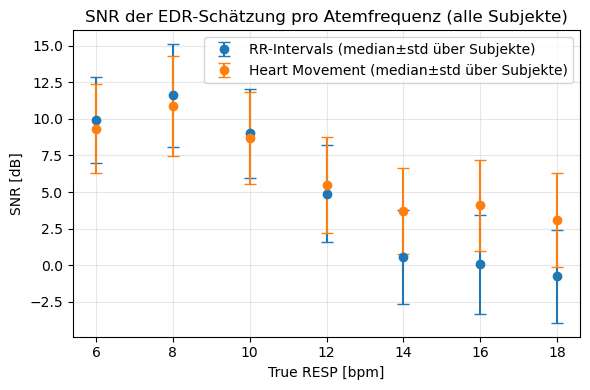

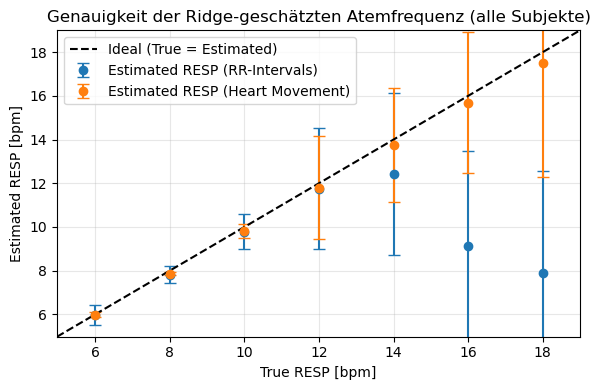

/var/folders/bn/421mrr_57mxdh0j6c5r7pt1c0000gn/T/ipykernel_40067/757755673.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["subject_id", "session_id"], group_keys=False).apply(compute_delta)


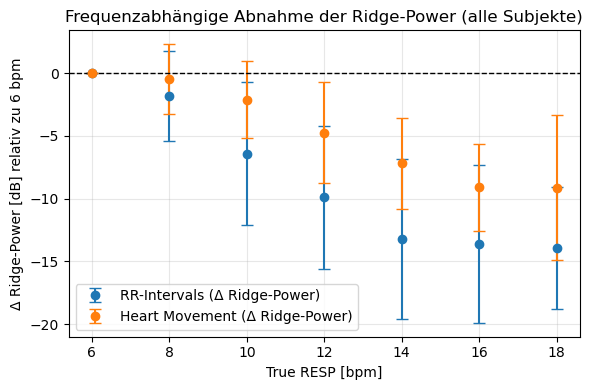

Delta-Plot gespeichert in: /Users/felixkuon/Desktop/EKG-Projekt/MA_PythonCode/ExecutableFolder/PaperPlots/AllSubjectsTogether/AllSubjects_RR_Intervals_HeartMovement_RidgePowerDelta_vs_bpm.png


In [ ]:
methods = ["RR_Intervals", "HeartMovement"]

plot_all_snr_vs_bpm(df_all_good, session_ids=methods)

plot_all_delta_ridge_power(df_all_good, session_ids=methods)

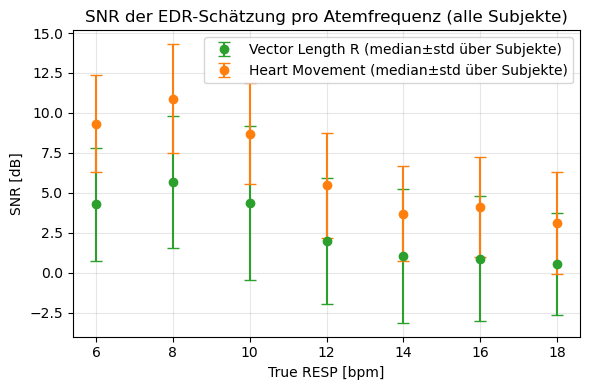

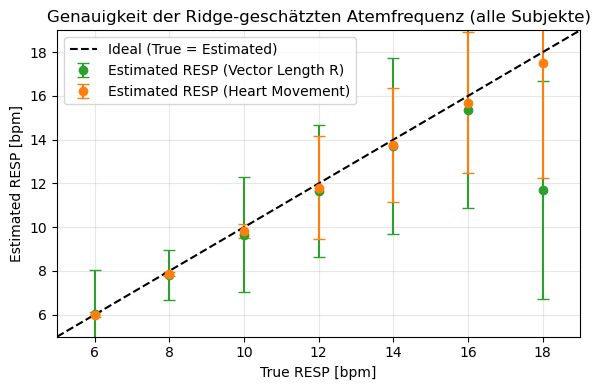

/var/folders/bn/421mrr_57mxdh0j6c5r7pt1c0000gn/T/ipykernel_40067/757755673.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["subject_id", "session_id"], group_keys=False).apply(compute_delta)


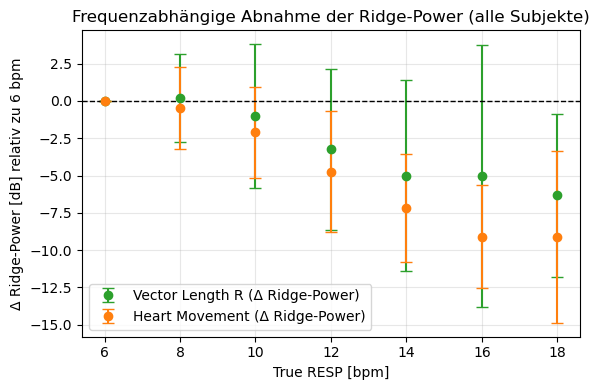

Delta-Plot gespeichert in: /Users/felixkuon/Desktop/EKG-Projekt/MA_PythonCode/ExecutableFolder/PaperPlots/AllSubjectsTogether/AllSubjects_VectorLength_R_HeartMovement_RidgePowerDelta_vs_bpm.png


In [ ]:
methods = ["VectorLength_R", "HeartMovement"]

plot_all_snr_vs_bpm(df_all_good, session_ids=methods)

plot_all_delta_ridge_power(df_all_good, session_ids=methods)


In [14]:
SESSION_LABELS = {
    "RR_Intervals": "RR-Intervals",
    "HeartMovement": "Heart Movement",
    "VectorLength_R": "Vector Length R",
    "Ensemble_RR_plus_HM": "Ensemble (RR+HM)",
}
SESSION_COLORS = {
    "RR_Intervals": "tab:blue",
    "HeartMovement": "tab:orange",
    "VectorLength_R": "tab:green",
    "Ensemble_RR_plus_HM": "tab:red",
}

def plot_error_vs_true_resp(df_all, session_ids=None, fname_suffix="", ylim=(-0.15, 0.15)):
    """
    Scatter-Plot: Error RESP (Hz) vs True RESP (Hz) über alle Segmente.

    - optional: session_ids = Liste von session_id-Strings zum Filtern
    - y-Achse: Error RESP (Hz) im Bereich [-0.3, 0.3]
    - x-Achse: True RESP (Hz)
    - horizontale Linien: mean(error) und mean(error) ± std(error)
    - Text: "Error: mean ± std Hz" oben im Plot
    - ylim: Tuple (ymin, ymax) für die y-Achse
    """
    df = df_all.copy()

    if session_ids is not None:
        df = df[df["session_id"].isin(session_ids)]
    if df.empty:
        print("[INFO] Keine Daten für die gewählten session_ids.")
        return

    df["true_resp_hz"] = df["bpm_target"] / 60.0
    df["est_resp_hz"]  = df["freq_median_hz"]
    df["error_hz"]     = df["est_resp_hz"] - df["true_resp_hz"]

    true_hz  = df["true_resp_hz"].values
    error_hz = df["error_hz"].values

    # IQR-Outlier-Filter
    q1 = np.percentile(error_hz, 15)
    q3 = np.percentile(error_hz, 85)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (error_hz >= lower) & (error_hz <= upper)

    df = df.loc[df.index[mask]].copy()
    true_hz  = df["true_resp_hz"].values
    error_hz = df["error_hz"].values

    mean_err = np.mean(error_hz)
    std_err  = np.std(error_hz, ddof=0)

    plt.figure(figsize=(6,4))

    # Punkte je Methode farblich
    for sid, g in df.groupby("session_id"):
        color = SESSION_COLORS.get(sid, "gray")
        label = SESSION_LABELS.get(sid, sid)
        plt.scatter(
            g["true_resp_hz"].values,
            g["error_hz"].values,
            s=8, alpha=0.5, color=color, label=label
        )

    # horizontale Linien
    plt.axhline(mean_err, color="k", linewidth=1.5)
    plt.axhline(mean_err + std_err, color="k", linestyle=":", linewidth=1.0)
    plt.axhline(mean_err - std_err, color="k", linestyle=":", linewidth=1.0)

    text = f"Error: {mean_err:.3f} ± {std_err:.3f} Hz"
    x_vals = df["true_resp_hz"].values
    x_text = x_vals.min() + 0.65 * (x_vals.max() - x_vals.min())
    y_text = ylim[1] * 0.9
    plt.text(x_text, y_text, text, ha="left", va="top")

    plt.ylim(ylim)
    plt.xlabel("True RESP (Hz)")
    plt.ylabel("Error RESP (Hz)")

    title_suffix = ""
    if session_ids is not None:
        title_suffix = " (" + ", ".join(session_ids) + ")"
    plt.title("RESP-Schätzfehler vs. wahre RESP" + title_suffix)

    plt.grid(alpha=0.3)
    plt.legend(markerscale=2)
    plt.tight_layout()

    if not fname_suffix:
        fname_suffix = "AllMethods" if session_ids is None else "_".join(session_ids)
    fname = f"AllSubjects_{fname_suffix}_Error_vs_TrueRESP.png"
    plt.savefig(os.path.join(plot_dir, fname), dpi=300)
    plt.show()

    print(f"Scatter-Plot gespeichert in: {fname}")
    print(f"Mittlerer Fehler: {mean_err:.3f} Hz, Std: {std_err:.3f} Hz, N={len(df)}")


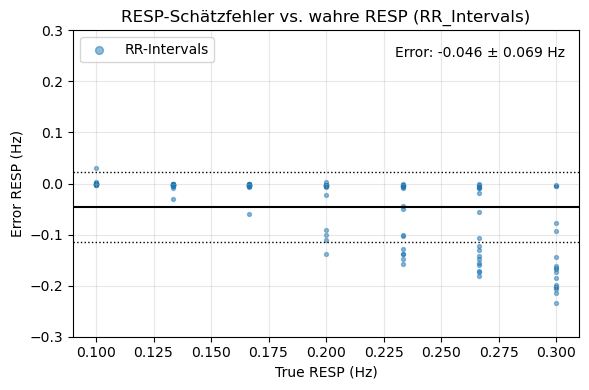

Scatter-Plot gespeichert in: AllSubjects_RR_Intervals_Error_vs_TrueRESP.png
Mittlerer Fehler: -0.046 Hz, Std: 0.069 Hz, N=125


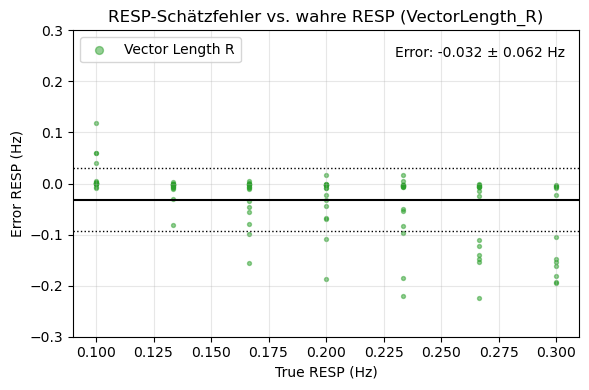

Scatter-Plot gespeichert in: AllSubjects_VectorLength_R_Error_vs_TrueRESP.png
Mittlerer Fehler: -0.032 Hz, Std: 0.062 Hz, N=119


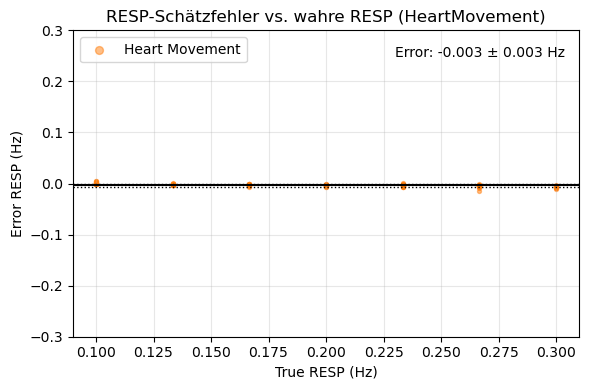

Scatter-Plot gespeichert in: AllSubjects_HeartMovement_Error_vs_TrueRESP.png
Mittlerer Fehler: -0.003 Hz, Std: 0.003 Hz, N=110


In [ ]:
# nur RR_Intervals
plot_error_vs_true_resp(df_all_good, session_ids=["RR_Intervals"], ylim=(-0.3, 0.3))
# nur VectorLength_R
plot_error_vs_true_resp(df_all_good, session_ids=["VectorLength_R"], ylim=(-0.3, 0.3))
# nur HeartMovement
plot_error_vs_true_resp(df_all_good, session_ids=["HeartMovement"], ylim=(-0.3, 0.3))

#plot_error_vs_true_resp(df_all_good, session_ids=["HeartMovement"], ylim=(-0.03, 0.03))


In [16]:
from scipy.stats import pearsonr

def plot_corr_true_vs_est(df_all, session_ids=None, fname_suffix="", xlim=None, ylim=None):
    """
    Scatter-Plot: True RESP (Hz) vs. Estimated RESP (Hz) für alle Methoden,
    mit Pearson-R pro Methode und insgesamt.
    """
    df = df_all.copy()

    if session_ids is not None:
        df = df[df["session_id"].isin(session_ids)]
    if df.empty:
        print("[INFO] Keine Daten für die gewählten session_ids.")
        return

    # in Hz
    df["true_resp_hz"] = df["bpm_target"] / 60.0
    df["est_resp_hz"]  = df["freq_median_hz"]

    # Ausreißer-Filter wie in deiner Fehlerfunktion
    error_hz = df["est_resp_hz"] - df["true_resp_hz"]
    q1 = np.percentile(error_hz, 15)
    q3 = np.percentile(error_hz, 85)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (error_hz >= lower) & (error_hz <= upper)

    N_total = len(df)              # vor Filter
    df = df.loc[df.index[mask]].copy()
    N_used = len(df)               # nach Filter

    # Gesamt-Korrelation
    x_all = df["true_resp_hz"].values
    y_all = df["est_resp_hz"].values
    if len(df) < 2:
        print("Zu wenige Punkte für Korrelation.")
        return
    r_all, p_all = pearsonr(x_all, y_all)

    plt.figure(figsize=(6,6))

    # Punkte nach Methode einfärben
    for sid, g in df.groupby("session_id"):
        color = SESSION_COLORS.get(sid, "gray")
        label = SESSION_LABELS.get(sid, sid)

        x = g["true_resp_hz"].values
        y = g["est_resp_hz"].values

        # Pearson-R pro Methode (wenn genug Punkte)
        if len(g) >= 2:
            r, p = pearsonr(x, y)
            label = f"{label} (R={r:.2f})"

        plt.scatter(x, y, s=8, alpha=0.5, color=color, label=label)

    # Diagonale (perfekte Übereinstimmung)
    x_min = x_all.min() if xlim is None else xlim[0]
    x_max = x_all.max() if xlim is None else xlim[1]
    y_min = y_all.min() if ylim is None else ylim[0]
    y_max = y_all.max() if ylim is None else ylim[1]

    lo = min(x_min, y_min)
    hi = max(x_max, y_max)
    plt.plot([lo, hi], [lo, hi], 'k--', linewidth=1, label="Identity")

    # Regressionslinie (Least Squares Fit) für alle Punkte
    slope, intercept = np.polyfit(x_all, y_all, 1)
    x_fit = np.linspace(lo, hi, 100)
    y_fit = slope * x_fit + intercept
    plt.plot(x_fit, y_fit, color="k", linewidth=1.5, label=f"Fit (R={r_all:.2f})")

    # Achsenlimits
    if xlim is not None:
        plt.xlim(xlim)
    else:
        plt.xlim(lo, hi)
    if ylim is not None:
        plt.ylim(ylim)
    else:
        plt.ylim(lo, hi)

    plt.xlabel("True RESP (Hz)")
    plt.ylabel("Estimated RESP (Hz)")

    title_suffix = ""
    if session_ids is not None:
        title_suffix = " (" + ", ".join(session_ids) + ")"
    plt.title(f"True vs. Estimated RESP{title_suffix}\nGesamt R = {r_all:.2f}")

    plt.grid(alpha=0.3)
    plt.legend(markerscale=2)
    plt.tight_layout()

    if not fname_suffix:
        fname_suffix = "AllMethods" if session_ids is None else "_".join(session_ids)
    fname = f"AllSubjects_{fname_suffix}_True_vs_EstRESP_Corr.png"
    plt.savefig(os.path.join(plot_dir, fname), dpi=300)
    plt.show()

    print(f"Scatter-Plot (Korrelation) gespeichert in: {fname}")
    print(
        f"Gesamt R = {r_all:.3f}, N={N_used} "
        f"(IQR-basiertes Ausreißerfilter mit Grenzen bei 15. und 85. Perzentil;"
        f"{N_used} von {N_total} verfügbaren Datenpunkten verwendet)"
    )


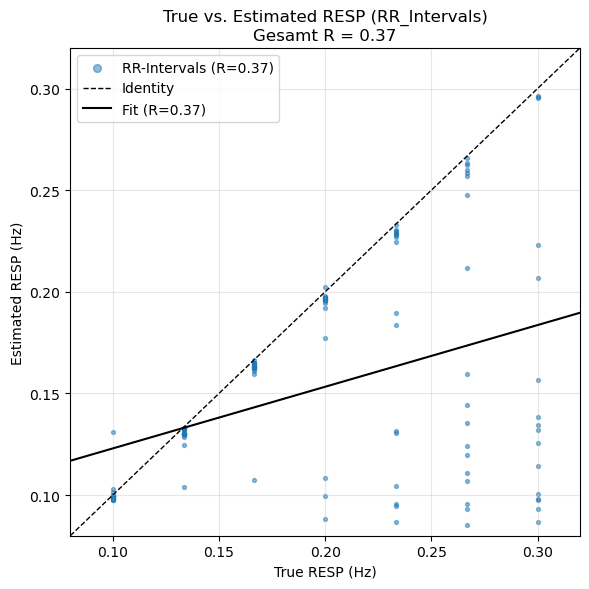

Scatter-Plot (Korrelation) gespeichert in: AllSubjects_RR_Intervals_True_vs_EstRESP_Corr.png
Gesamt R = 0.366, N=125 (IQR-basiertes Ausreißerfilter mit Grenzen bei 15. und 85. Perzentil;125 von 125 verfügbaren Datenpunkten verwendet)


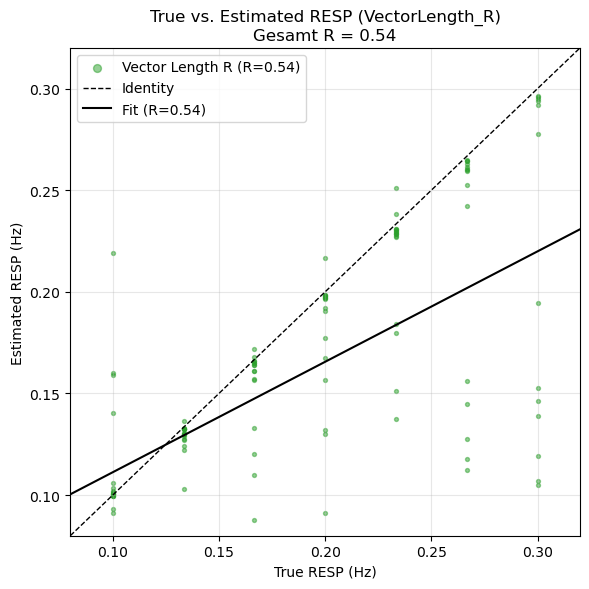

Scatter-Plot (Korrelation) gespeichert in: AllSubjects_VectorLength_R_True_vs_EstRESP_Corr.png
Gesamt R = 0.543, N=119 (IQR-basiertes Ausreißerfilter mit Grenzen bei 15. und 85. Perzentil;119 von 119 verfügbaren Datenpunkten verwendet)


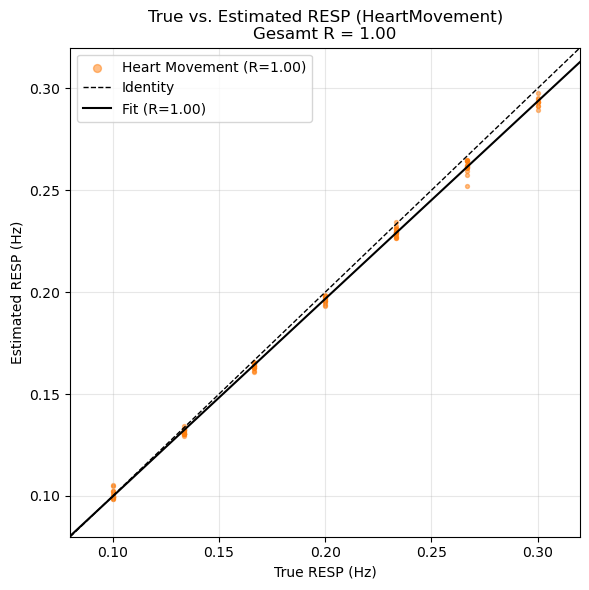

Scatter-Plot (Korrelation) gespeichert in: AllSubjects_HeartMovement_True_vs_EstRESP_Corr.png
Gesamt R = 0.999, N=110 (IQR-basiertes Ausreißerfilter mit Grenzen bei 15. und 85. Perzentil;110 von 125 verfügbaren Datenpunkten verwendet)


In [17]:
# nur RR_Intervals
plot_corr_true_vs_est(df_all_good, session_ids=["RR_Intervals"], ylim=(0.08, 0.32))
# nur VectorLength_R
plot_corr_true_vs_est(df_all_good, session_ids=["VectorLength_R"], ylim=(0.08, 0.32))
# nur HeartMovement
plot_corr_true_vs_est(df_all_good, session_ids=["HeartMovement"], ylim=(0.08, 0.32))